# NBA Playoff Success Prediction — The Championship Contender Detector

## Question & Background

**Primary question:** *Can regular-season statistics predict how far an NBA team will advance in the playoffs well enough to outperform the naive "trust the top seeds" baseline?*

This addresses the question asked at the beginning of every playoffs: is a team a true contender, or just a pretender? Our model maps each team's regular-season profile to a predicted playoff depth, and derives a champion pick. The goal is to beat the simple "trust the higher seed" baseline.

**Ladder framing.** We treat playoff success as an ordinal outcome (0 = missed playoffs, 1 = lost 1st round, 2 = lost 2nd round, 3 = lost Conf Finals, 4 = lost Finals, 5 = won championship). A team that loses in the Finals is closer to a champion than a team that loses in the 1st round — the ladder captures that ordering.

**What this is and isn't.** This is not a perfect predictor of every team's exit round. Playoff series have high variance, and matchups and injuries cause randomness the model can't see. What this model is trained to do is sort teams into tiers; the model's high-confidence contenders should advance further on average than its low-confidence picks, and further than the seed-based baseline predicts.

**Data.** The Kaggle [NBA Database (`wyattowalsh/basketball`)](https://www.kaggle.com/datasets/wyattowalsh/basketball) — CSV files covering NBA games from 1946 to 2023. We narrow to 2002-2003 season onward so every season uses best-of-7 first round (champions need 16 wins, keeping the ladder labels clean).

**Why this topic.** It sits at the intersection of sports analysis and data science. As basketball fans, we thought it would be especially interesting to build this while the actual NBA playoffs are happening.

In [1]:
# Packages
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    accuracy_score, mean_absolute_error, r2_score,
    precision_score, recall_score, roc_auc_score, f1_score,
)
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)


In [2]:
# Load the game data
games_raw = pd.read_csv('game.csv')

print(f"Loaded {len(games_raw):,} games")
print(f"Columns: {len(games_raw.columns)}")
print(f"Date range: {games_raw['game_date'].min()} → {games_raw['game_date'].max()}")
print(f"\nSeason types:")
print(games_raw['season_type'].value_counts())
games_raw.head(3)


Loaded 65,698 games
Columns: 55
Date range: 1946-11-01 00:00:00 → 2023-06-12 00:00:00

Season types:
season_type
Regular Season    60192
Playoffs           3842
Pre Season         1536
All Star             65
All-Star             63
Name: count, dtype: int64


,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,...,team_abbreviation_away,team_name_away,matchup_away,wl_away,fgm_away,fga_away,fg_pct_away,fg3m_away,fg3a_away,fg3_pct_away,ftm_away,fta_away,ft_pct_away,oreb_away,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away,season_type
0,21946,1610610035,HUS,Toronto Huskies,24600001,1946-11-01 00:00:00,HUS vs. NYK,L,0,25.0,NaN,NaN,NaN,NaN,NaN,16.0,29.0,0.552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NYK,New York Knicks,NYK @ HUS,W,24.0,NaN,NaN,NaN,NaN,NaN,20.0,26.0,0.769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.0,2,0,Regular Season
1,21946,1610610034,BOM,St. Louis Bombers,24600003,1946-11-02 00:00:00,BOM vs. PIT,W,0,20.0,59.0,0.339,NaN,NaN,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,PIT,Pittsburgh Ironmen,PIT @ BOM,L,16.0,72.0,0.222,NaN,NaN,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,51.0,-5,0,Regular Season
2,21946,1610610032,PRO,Providence Steamrollers,24600002,1946-11-02 00:00:00,PRO vs. BOS,W,0,21.0,NaN,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,BOS,Boston Celtics,BOS @ PRO,L,21.0,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.0,-6,0,Regular Season


## Data Cleaning Pipeline


1. **Filter to the 2002-03 season onward.** The 2002-03 season is the first under the modern best-of-7 first-round format, so every champion requires exactly 16 playoff wins. This keeps the ordinal target labels clean (pre-2003 champions only had 15 wins because the 1st round was best-of-5, which would mis-classify them as Finals losers under our `1 + wins // 4` mapping).

2. **Separate regular season from playoffs.** Filter using `season_type` column: "Regular Season" for features, "Playoffs" for the target.

3. **Unstack games to team perspective.** The raw data has one row per game with both teams' stats side-by-side. We split each game into two rows — one from the home team's perspective, one from the away team's — so every row represents one team's performance in one game. This long format lets us group by team and aggregate their stats across the season.

4. **Build team-season aggregates (features).** For each team in each season, compute their regular-season averages: points, points allowed, FG%, 3P%, rebounds, assists, turnovers, plus engineered features (strength of schedule, last-20-games form, form delta).

5. **Build the playoff ladder (target).** For each team in each season, count playoff wins. Map to ordinal scale: 16 wins = champion (5), 12-15 = Finals loser (4), 8-11 = Conf Finals (3), 4-7 = 2nd round (2), 0-3 = 1st round (1, includes 0-win sweeps), missed playoffs = 0.

6. **Merge features + target.** One row per team-season, with regular-season stats as features and playoff outcome as target.



In [3]:
# STEP 1 — Filter to the 2003-onward era

games = games_raw.copy()
games['game_date'] = pd.to_datetime(games['game_date'])
games['season'] = games['season_id'] % 10000   
games = games[games['season'] >= 2002].copy()    

print(f"After filtering to season >= 2002 (the 2002-03 season onward):")
print(f"  Total games: {len(games):,}")
print(f"  Seasons: {games['season'].min()}-{games['season'].max()}")
print(f"  Date range: {games['game_date'].min()} → {games['game_date'].max()}")
print(f"\nGames by season type:")
print(games['season_type'].value_counts())


After filtering to season >= 2002 (the 2002-03 season onward):
  Total games: 27,205
  Seasons: 2002-2022
  Date range: 2002-10-29 00:00:00 → 2023-06-12 00:00:00

Games by season type:
season_type
Regular Season    23957
Playoffs           1674
Pre Season         1536
All Star             20
All-Star             18
Name: count, dtype: int64


In [4]:
# STEP 2 — Separate regular season from playoffs
regular = games[games['season_type'] == 'Regular Season'].copy()
playoff = games[games['season_type'] == 'Playoffs'].copy()

print(f"Regular season: {len(regular):,} games ({regular['season'].min()}-{regular['season'].max()})")
print(f"Playoffs: {len(playoff):,} games ({playoff['season'].min()}-{playoff['season'].max()})")
print(f"\nUnique teams (home): {regular['team_abbreviation_home'].nunique()}")


Regular season: 23,957 games (2002-2022)
Playoffs: 1,674 games (2002-2022)

Unique teams (home): 34


In [5]:
# STEP 3 — Unstack games to team perspective (long format)


STAT_COLS = ['fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct','ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts']

def perspective(df, side, opp):
    """Return one row per game from `side`'s perspective (home or away)."""
    out = df[['game_id', 'season', 'season_id', 'game_date']].copy()
    out['team'] = df[f'team_abbreviation_{side}']
    out['opponent'] = df[f'team_abbreviation_{opp}']
    out['won']  = (df[f'wl_{side}'] == 'W').astype(int)
    out['pts_opp'] = df[f'pts_{opp}']
    for c in STAT_COLS:
        out[c] = df[f'{c}_{side}']
    return out

def unstack_games(df):
    return pd.concat(
        [perspective(df, 'home', 'away'), perspective(df, 'away', 'home')],
        ignore_index=True,)

regular_long = unstack_games(regular)
playoff_long = unstack_games(playoff)

print(f"Regular season (long): {len(regular_long):,} team-game observations")
print(f"Playoffs (long): {len(playoff_long):,} team-game observations")
print(f"\nColumns available: {list(regular_long.columns)}")


Regular season (long): 47,914 team-game observations
Playoffs (long): 3,348 team-game observations

Columns available: ['game_id', 'season', 'season_id', 'game_date', 'team', 'opponent', 'won', 'pts_opp', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts']


In [6]:
# STEP 4 — Aggregate regular-season stats by team + season

mean_cols = ['pts', 'pts_opp', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'stl', 'blk', 'tov', 'fga', 'fg3a']

team_seasons = (regular_long.groupby(['season', 'team']).agg(games_played=('game_id', 'count'), won=('won', 'sum'), **{c: (c, 'mean') for c in mean_cols}).reset_index())

# Core derived features
team_seasons['net_rating'] = team_seasons['pts'] - team_seasons['pts_opp']
team_seasons['win_pct']    = team_seasons['won'] / team_seasons['games_played']
team_seasons['three_rate'] = team_seasons['fg3a'] / team_seasons['fga']

# Strength of Schedule (avg opponent win%)
opp_winpct = team_seasons[['season', 'team', 'win_pct']].rename(columns={'team': 'opponent', 'win_pct': 'opp_win_pct'})
sos = (regular_long.merge(opp_winpct, on=['season', 'opponent']).groupby(['season', 'team'])['opp_win_pct'].mean().reset_index(name='sos'))
team_seasons = team_seasons.merge(sos, on=['season', 'team'])

# Late-season form (last 20 regular-season games) 
# Captures momentum / injuries leading into the playoffs.
late = (regular_long.sort_values(['season', 'team', 'game_date']).groupby(['season', 'team']).tail(20).groupby(['season', 'team']).agg(late_pts=('pts', 'mean'),late_pts_opp=('pts_opp', 'mean'), late_win_pct=('won', 'mean')).reset_index())
late['late_net_rating'] = late['late_pts'] - late['late_pts_opp']
team_seasons = team_seasons.merge(late[['season', 'team', 'late_net_rating', 'late_win_pct']],on=['season', 'team'])

# Form delta: how much better/worse late vs full season
team_seasons['form_delta'] = team_seasons['late_net_rating'] - team_seasons['net_rating']


print(f"Team-season aggregates: {team_seasons.shape}")
print(f"\n New Features:")
print(team_seasons[['season', 'team', 'net_rating', 'sos', 'late_net_rating', 'form_delta']].head())


Team-season aggregates: (598, 23)

 New Features:
   season team  net_rating       sos  late_net_rating  form_delta
0    2002  ATL   -3.560976  0.491077            -1.70    1.860976
1    2002  BOS   -0.390244  0.489738            -1.85   -1.459756
2    2002  CHI   -5.134146  0.497620            -5.70   -0.565854
3    2002  CLE   -9.621951  0.505354            -6.00    3.621951
4    2002  DAL    7.780488  0.500595             2.90   -4.880488


In [7]:
# STEP 5 — Build the playoff ladder (target variable)

playoff_summary = playoff_long.groupby(['season', 'team']).agg(
    playoff_games=('game_id', 'count'),
    playoff_wins=('won', 'sum'),
).reset_index()

# create a "ladder score" based on playoff wins (0-5 scale)
playoff_summary['ladder_score'] = np.minimum(1 + playoff_summary['playoff_wins'] // 4, 5)

print(f"Playoff summary: {playoff_summary.shape}")
print(f"\nLadder score distribution (playoff teams only):")
print(playoff_summary['ladder_score'].value_counts().sort_index())
print(f"\nPlayoff wins summary (champions have 16):")
print(playoff_summary['playoff_wins'].describe())
print(f"\nSample champions (ladder_score = 5):")
print(playoff_summary[playoff_summary['ladder_score'] == 5][['season', 'team', 'playoff_wins']].tail(10))


Playoff summary: (320, 5)

Ladder score distribution (playoff teams only):
ladder_score
1    160
2     80
3     40
4     20
5     20
Name: count, dtype: int64

Playoff wins summary (champions have 16):
count    320.000000
mean       5.231250
std        4.729978
min        0.000000
25%        1.000000
50%        3.500000
75%        7.250000
max       16.000000
Name: playoff_wins, dtype: float64

Sample champions (ladder_score = 5):
     season team  playoff_wins
173    2013  SAS            16
182    2014  GSW            16
195    2015  CLE            16
212    2016  GSW            16
226    2017  GSW            16
254    2018  TOR            16
263    2019  LAL            16
281    2020  MIL            16
294    2021  GSW            16
308    2022  DEN            16


In [8]:
# STEP 6 — Merge regular-season features with playoff outcomes
df = team_seasons.merge(
    playoff_summary[['season', 'team', 'ladder_score', 'playoff_wins']],
    on=['season', 'team'],
    how='left'
)

# Teams that didn't make playoffs: ladder_score = 0
df['ladder_score'] = df['ladder_score'].fillna(0).astype(int)
df['playoff_wins'] = df['playoff_wins'].fillna(0).astype(int)
df['made_playoffs'] = (df['ladder_score'] > 0).astype(int)

# Drop any rows with missing regular-season stats (shouldn't be any, but defensive)
print(f"Before dropping missing: {df.shape}")
df = df.dropna(subset=['net_rating', 'pts', 'pts_opp'])
print(f"After dropping missing: {df.shape}")

print(f"\nFinal dataset:")
print(f"  {len(df)} team-seasons")
print(f"  {df['season'].nunique()} seasons ({df['season'].min()}-{df['season'].max()})")
print(f"  {df['team'].nunique()} unique teams")
print(f"  {df['made_playoffs'].sum()} made playoffs ({df['made_playoffs'].mean()*100:.1f}%)")
print(f"\nLadder score distribution:")
print(df['ladder_score'].value_counts().sort_index())

df.head()


Before dropping missing: (598, 26)
After dropping missing: (598, 26)

Final dataset:
  598 team-seasons
  20 seasons (2002-2022)
  34 unique teams
  304 made playoffs (50.8%)

Ladder score distribution:
ladder_score
0    294
1    152
2     76
3     38
4     19
5     19
Name: count, dtype: int64


,season,team,games_played,won,pts,pts_opp,fg_pct,fg3_pct,ft_pct,reb,ast,stl,blk,tov,fga,fg3a,net_rating,win_pct,three_rate,sos,late_net_rating,late_win_pct,form_delta,ladder_score,playoff_wins,made_playoffs
0,2002,ATL,82,35,94.073171,97.634146,0.444963,0.354976,0.788634,42.621951,20.475610,7.451220,5.768293,16.670732,78.463415,13.914634,-3.560976,0.426829,0.177339,0.491077,-1.70,0.55,1.860976,0,0,0
1,2002,BOS,82,44,92.670732,93.060976,0.415073,0.330110,0.738085,40.487805,19.207317,8.780488,3.695122,13.987805,79.378049,26.280488,-0.390244,0.536585,0.331080,0.489738,-1.85,0.40,-1.459756,2,4,1
2,2002,CHI,82,30,94.951220,100.085366,0.446524,0.342451,0.725488,43.000000,21.731707,7.378049,5.621951,16.926829,81.878049,12.158537,-5.134146,0.365854,0.148496,0.497620,-5.70,0.45,-0.565854,0,0,0
3,2002,CLE,82,17,91.402439,101.024390,0.422976,0.303659,0.746390,44.634146,20.878049,7.756098,6.353659,18.268293,82.268293,10.926829,-9.621951,0.207317,0.132819,0.505354,-6.00,0.30,3.621951,0,0,0
4,2002,DAL,82,60,102.975610,95.195122,0.453280,0.377585,0.827829,42.146341,22.402439,8.109756,5.475610,11.560976,85.146341,20.341463,7.780488,0.731707,0.238900,0.500595,2.90,0.60,-4.880488,3,10,1


## Exploratory Data Analysis


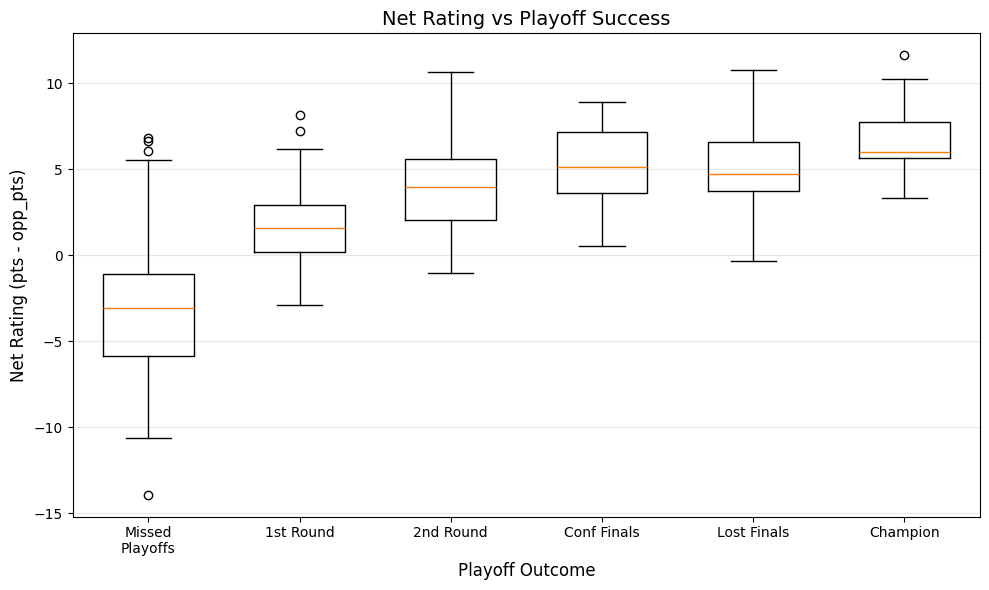

Net rating by ladder score (mean ± std):
              mean   std  count
ladder_score                   
0            -3.36  3.45    294
1             1.74  2.04    152
2             3.89  2.61     76
3             5.24  2.09     38
4             4.96  2.52     19
5             6.76  2.15     19


In [9]:
# EDA 1 — Net rating distribution by playoff outcome
fig, ax = plt.subplots(figsize=(10, 6))

ladder_labels = {0: 'Missed\nPlayoffs', 1: '1st Round', 2: '2nd Round', 3: 'Conf Finals', 4: 'Lost Finals', 5: 'Champion'}
df['ladder_label'] = df['ladder_score'].map(ladder_labels)

order = sorted(df['ladder_score'].unique())
data = [df.loc[df['ladder_score'] == s, 'net_rating'].dropna().values for s in order]
labels = [ladder_labels[s] for s in order]

ax.boxplot(data, labels=labels, widths=0.6)
ax.set_xlabel('Playoff Outcome', fontsize=12)
ax.set_ylabel('Net Rating (pts - opp_pts)', fontsize=12)
ax.set_title('Net Rating vs Playoff Success', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Net rating by ladder score (mean ± std):")
print(df.groupby('ladder_score')['net_rating'].agg(['mean', 'std', 'count']).round(2))


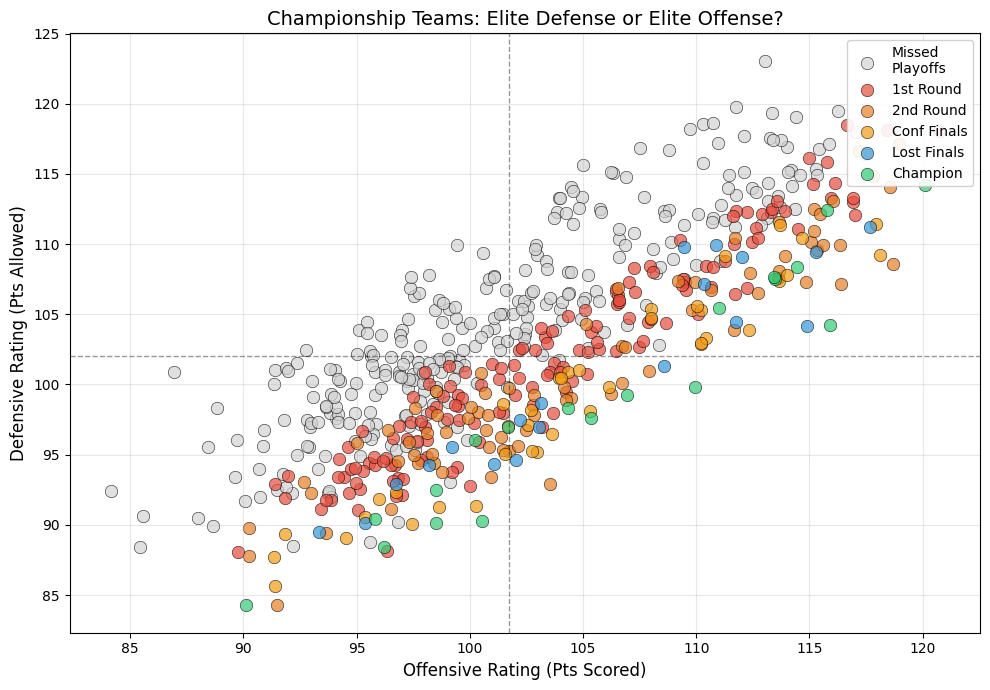


Champions vs Non-Playoff Teams:
  Champions avg pts:     105.9  (vs 101.0 for non-playoff)
  Champions avg pts_opp: 99.2  (vs 104.4 for non-playoff)
  Champions net rating:  6.8  (vs -3.4)


In [10]:
# EDA 2 — Offense vs Defense: Which matters more for deep runs?
fig, ax = plt.subplots(figsize=(10, 7))

colors = {0: 'lightgray', 1: '#e74c3c', 2: '#e67e22', 3: '#f39c12', 4: '#3498db', 5: '#2ecc71'}
for score in sorted(df['ladder_score'].unique()):
    subset = df[df['ladder_score'] == score]
    ax.scatter(subset['pts'], subset['pts_opp'],
               c=colors.get(score, 'gray'), label=ladder_labels[score],
               alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Offensive Rating (Pts Scored)', fontsize=12)
ax.set_ylabel('Defensive Rating (Pts Allowed)', fontsize=12)
ax.set_title('Championship Teams: Elite Defense or Elite Offense?', fontsize=14)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)

# Add quadrant lines at median
league_med_off = df['pts'].median()
league_med_def = df['pts_opp'].median()
ax.axvline(league_med_off, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(league_med_def, color='black', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.show()

print("\nChampions vs Non-Playoff Teams:")
champs = df[df['ladder_score'] == 5]
missed = df[df['ladder_score'] == 0]
print(f"  Champions avg pts:     {champs['pts'].mean():.1f}  (vs {missed['pts'].mean():.1f} for non-playoff)")
print(f"  Champions avg pts_opp: {champs['pts_opp'].mean():.1f}  (vs {missed['pts_opp'].mean():.1f} for non-playoff)")
print(f"  Champions net rating:  {champs['net_rating'].mean():.1f}  (vs {missed['net_rating'].mean():.1f})")


In [11]:
# EDA 3 — Feature correlations with playoff success
corr_features = ['ladder_score', 'net_rating', 'pts', 'pts_opp', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov', 'win_pct']

corr_matrix = df[corr_features].corr()['ladder_score'].drop('ladder_score').sort_values(ascending=False)

print("Correlations with ladder_score (playoff success):")
print(corr_matrix.round(3))
print(f"\nKey finding: Net rating correlation = {corr_matrix['net_rating']:.3f}")
print(f"Win % correlation = {corr_matrix['win_pct']:.3f}")
print("(Higher net rating → deeper playoff runs)")


Correlations with ladder_score (playoff success):
win_pct       0.731
net_rating    0.708
fg_pct        0.415
fg3_pct       0.351
ast           0.248
pts           0.216
reb           0.191
ft_pct        0.140
tov          -0.171
pts_opp      -0.217
Name: ladder_score, dtype: float64

Key finding: Net rating correlation = 0.708
Win % correlation = 0.731
(Higher net rating → deeper playoff runs)


### EDA Takeaways

Three clear patterns emerge:

1. **Net rating and win percentage are the top predictors.** As net rating rises, teams consistently advance further in the playoffs. It correlates strongly with ladder score (r ≈ 0.71), just behind win percentage (r ≈ 0.73). Championship teams typically fall in the +6 to +8 range, compared to about −3 for non-playoff teams.

2. **Champions are above-average on both sides of the ball, not just one.** Champions outscore opponents by ~6.8 pts/game, while non-playoff teams are outscored by ~3.4 pts/game — a roughly ~10.1 pt/game swing between the two extremes.

3. **Shooting efficiency (FG%, 3P%, FT%) correlates moderately.** These distinguish good teams from bad teams (FG% correlation ~0.42) but don't separate deep-playoff teams as cleanly as net rating does.

**What this means for modeling:** Win % and net rating will dominate feature importance. The model's job is to find additional signal beyond those two, like strength of schedule and shooting efficiency.

## The Baseline — Seed-Based Historical Probabilities

The naive prediction: trust the top seeds. The dataset doesn't include explicit seeds, so we infer them by ranking teams within each season by win % (with net rating as tiebreak).

The baseline predicts each team will achieve the *modal* historical outcome for their seed (e.g. if 30% of 1-seeds reach Conf Finals, all 1-seeds get predicted Conf Finals). We measure both with **MAE** (rounds off) and **accuracy** (exact matches).

In [12]:
# BASELINE — Infer seeds by ranking teams WITHIN each conference


EAST_TEAMS = {'ATL','BOS','BKN','NJN','CHA','CHI','CLE','DET','IND',
              'MIA','MIL','NYK','ORL','PHI','TOR','WAS'}
WEST_TEAMS = {'DAL','DEN','GSW','HOU','LAC','LAL','MEM','MIN','NOP',
              'NOH','NOK','OKC','SEA','PHX','POR','SAC','SAS','UTA'}

_conf_map = {**{t: 'East' for t in EAST_TEAMS}, **{t: 'West' for t in WEST_TEAMS}}
df['conference'] = df['team'].map(_conf_map)
unmapped = df.loc[df['conference'].isna(), 'team'].unique()
assert len(unmapped) == 0, f'Unmapped teams: {unmapped}'

# Rank within (season, conference) — 1 = best in conference
df = df.sort_values(
    ['season', 'conference', 'win_pct', 'net_rating'],
    ascending=[True, True, False, False],
)
df['seed'] = df.groupby(['season', 'conference']).cumcount() + 1

print('Seed distribution (per-conference; top 8 = playoff seeds):')
print(df['seed'].value_counts().sort_index().head(15))

print(f"\nSample: 2022 season seeds by conference")
sample_2022 = (df[df['season'] == 2022]
    [['season','team','conference','seed','win_pct','net_rating','ladder_score']]
    .sort_values(['conference','seed']))
print(sample_2022.to_string(index=False))


Seed distribution (per-conference; top 8 = playoff seeds):
seed
1     40
2     40
3     40
4     40
5     40
6     40
7     40
8     40
9     40
10    40
11    40
12    40
13    40
14    40
15    38
Name: count, dtype: int64

Sample: 2022 season seeds by conference
 season team conference  seed  win_pct  net_rating  ladder_score
   2022  MIL       East     1 0.707317    3.634146             1
   2022  BOS       East     2 0.695122    6.524390             3
   2022  PHI       East     3 0.658537    4.317073             2
   2022  CLE       East     4 0.621951    5.378049             1
   2022  NYK       East     5 0.573171    2.926829             2
   2022  BKN       East     6 0.548780    0.853659             1
   2022  MIA       East     7 0.536585   -0.317073             4
   2022  TOR       East     8 0.500000    1.475610             0
   2022  ATL       East     9 0.500000    0.292683             1
   2022  CHI       East    10 0.487805    1.292683             0
   2022  WAS       

In [13]:
# Compute historical success rate by seed (for playoff teams)
playoff_teams = df[df['made_playoffs'] == 1].copy()

baseline_table = playoff_teams.groupby('seed')['ladder_score'].value_counts(normalize=True).unstack(fill_value=0)
print(f"Historical playoff outcomes by seed (top 10 seeds):")
print(baseline_table.head(10).round(3))

# Modal outcome per seed
baseline_mode = playoff_teams.groupby('seed')['ladder_score'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 0)
print(f"\nModal (most common) outcome per seed (top 10):")
print(baseline_mode.head(10))

# Apply baseline prediction
df['baseline_pred'] = df['seed'].map(baseline_mode).fillna(0).astype(int)

# Baseline MAE and accuracy
baseline_mae = mean_absolute_error(df['ladder_score'], df['baseline_pred'])
baseline_acc = accuracy_score(df['ladder_score'], df['baseline_pred'])

print(f"\nBaseline performance (all teams, n={len(df)}):")
print(f"  Accuracy (exact round): {baseline_acc:.3f}")
print(f"  MAE (rounds off):       {baseline_mae:.3f}")
print("\nThis is the bar our models must beat.")


Historical playoff outcomes by seed (top 10 seeds):
ladder_score      1      2      3      4      5
seed                                           
1             0.105  0.158  0.421  0.079  0.237
2             0.079  0.342  0.184  0.237  0.158
3             0.184  0.447  0.184  0.079  0.105
4             0.421  0.395  0.132  0.053  0.000
5             0.579  0.342  0.053  0.026  0.000
6             0.789  0.211  0.000  0.000  0.000
7             0.892  0.054  0.027  0.027  0.000
8             0.926  0.074  0.000  0.000  0.000
9             1.000  0.000  0.000  0.000  0.000
10            1.000  0.000  0.000  0.000  0.000

Modal (most common) outcome per seed (top 10):
seed
1     3
2     2
3     2
4     1
5     1
6     1
7     1
8     1
9     1
10    1
Name: ladder_score, dtype: int64

Baseline performance (all teams, n=598):
  Accuracy (exact round): 0.639
  MAE (rounds off):       0.477

This is the bar our models must beat.


## Methods — Predicting the Playoff Ladder

We train **four approaches** that predict ladder_score (0–5) using regular-season stats. The target is ordinal but we treat it as **regression**: predict a continuous score, then round and clip to [0, 5].

1. **Ridge Regression** 
2. **Decision Tree** 
3. **Random Forest** 
4. **k-Nearest Neighbors** 
**Train/Test Split:** time-based — train on 2002–2018, test on 2019–2022. We start at 2002 so every champion requires 16 wins (modern best-of-7 first round) and the ladder labels are clean.

**Features (18 total):** net rating, pts, pts_opp, win_pct, seed, shooting efficiency (FG%, 3P%, FT%), rebounds, assists, turnovers, steals, blocks, three-point rate, plus engineered features (strength of schedule, last-20-games net rating + win%, form delta).



In [14]:
# METHODS SETUP — features and time-based split
RANDOM_STATE = 42
TEST_SEASON_START = 2019  # train on 2002-2018, test on 2019-2022

# Features — original set + 4 engineered features
feature_cols = ['net_rating', 'pts', 'pts_opp', 'win_pct', 'seed','fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov', 'stl', 'blk', 'three_rate','sos', 'late_net_rating', 'late_win_pct', 'form_delta']

print(f"Using {len(feature_cols)} features: {feature_cols}")

# Time-based split — never random for time-series data
train = df[df['season'] < TEST_SEASON_START].copy()
test  = df[df['season'] >= TEST_SEASON_START].copy()

X_train = train[feature_cols]
y_train = train['ladder_score']
X_test  = test[feature_cols]
y_test  = test['ladder_score']

print(f"\nTrain: {X_train.shape}  (seasons {train['season'].min()}-{train['season'].max()})")
print(f"Test:  {X_test.shape}  (seasons {test['season'].min()}-{test['season'].max()})")
print(f"\nTarget distribution (train):")
print(y_train.value_counts().sort_index())

# Helper: round a regression prediction back to the ordinal 0–5 ladder.
def to_ladder(raw):
    return np.clip(np.round(raw), 0, 5).astype(int)


Using 18 features: ['net_rating', 'pts', 'pts_opp', 'win_pct', 'seed', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov', 'stl', 'blk', 'three_rate', 'sos', 'late_net_rating', 'late_win_pct', 'form_delta']

Train: (478, 18)  (seasons 2002-2018)
Test:  (120, 18)  (seasons 2019-2022)

Target distribution (train):
ladder_score
0    238
1    120
2     60
3     30
4     15
5     15
Name: count, dtype: int64


In [15]:
# MODEL 1 — Ridge / Linear Regression

model_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
model_1.fit(X_train, y_train)

y_pred_1_raw = model_1.predict(X_test)
y_pred_1 = to_ladder(y_pred_1_raw)

mae_1 = mean_absolute_error(y_test, y_pred_1)
acc_1 = accuracy_score(y_test, y_pred_1)
r2_1 = r2_score(y_test, y_pred_1_raw)

print(f"Model 1 (Ridge / Linear Regression) — Test MAE: {mae_1:.3f}  Accuracy: {acc_1:.3f}  R²: {r2_1:.3f}")

# Top coefficients (read from the inner Ridge step of the pipeline)
ridge_coefs = model_1.named_steps['ridge'].coef_
coef_df = pd.DataFrame({'feature': feature_cols, 'coef': ridge_coefs}).sort_values('coef', key=abs, ascending=False)
print(f"\nTop 5 features by |coefficient|:")
print(coef_df.head(5).to_string(index=False))


Model 1 (Ridge / Linear Regression) — Test MAE: 0.533  Accuracy: 0.558  R²: 0.593

Top 5 features by |coefficient|:
   feature      coef
      seed -0.954904
    fg_pct  0.202585
three_rate  0.184451
   pts_opp -0.112246
       tov  0.110106


In [16]:
# MODEL 2 — Decision Tree Regressor with CV tuning on max_depth
depths = [3, 5, 7, 9, 11]
cv_scores = {}
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, min_samples_leaf=20, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_absolute_error')
    cv_scores[d] = -scores.mean()
    print(f"max_depth={d}  CV MAE={cv_scores[d]:.3f}")

best_depth = min(cv_scores, key=cv_scores.get)
print(f"\nBest depth: {best_depth}")

model_2 = DecisionTreeRegressor(max_depth=best_depth, min_samples_leaf=20, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)

y_pred_2_raw = model_2.predict(X_test)
y_pred_2 = to_ladder(y_pred_2_raw)

mae_2 = mean_absolute_error(y_test, y_pred_2)
acc_2 = accuracy_score(y_test, y_pred_2)
r2_2 = r2_score(y_test, y_pred_2_raw)

print(f"\nModel 2 (Tree, depth={best_depth}) — Test MAE: {mae_2:.3f}  Accuracy: {acc_2:.3f}  R²: {r2_2:.3f}")


max_depth=3  CV MAE=0.461
max_depth=5  CV MAE=0.456
max_depth=7  CV MAE=0.456
max_depth=9  CV MAE=0.456
max_depth=11  CV MAE=0.456

Best depth: 5

Model 2 (Tree, depth=5) — Test MAE: 0.467  Accuracy: 0.642  R²: 0.539


In [17]:
# MODEL 3 — Random Forest Regressor
model_3 = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=15,
    max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE
)
model_3.fit(X_train, y_train)

y_pred_3_raw = model_3.predict(X_test)
y_pred_3 = to_ladder(y_pred_3_raw)

mae_3 = mean_absolute_error(y_test, y_pred_3)
acc_3 = accuracy_score(y_test, y_pred_3)
r2_3 = r2_score(y_test, y_pred_3_raw)

print(f"Model 3 (Forest) — Test MAE: {mae_3:.3f}  Accuracy: {acc_3:.3f}  R²: {r2_3:.3f}")

# Feature importances
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_3.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 5 features by importance:")
print(importances.head(5).to_string(index=False))


Model 3 (Forest) — Test MAE: 0.458  Accuracy: 0.642  R²: 0.606

Top 5 features by importance:
        feature  importance
           seed    0.283348
        win_pct    0.216246
     net_rating    0.197294
late_net_rating    0.083243
   late_win_pct    0.055037


In [18]:
# MODEL 4 — k-Nearest Neighbors Regressor 
ks = [3, 5, 7, 11, 15, 21]
cv_scores_knn = {}
for k in ks:
    knn_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsRegressor(n_neighbors=k, weights='distance')),
    ])
    cv_mae = -cross_val_score(knn_pipe, X_train, y_train, cv=3,
                              scoring='neg_mean_absolute_error').mean()
    cv_scores_knn[k] = cv_mae
    print(f"n_neighbors={k:>2}  CV MAE={cv_mae:.3f}")

best_k = min(cv_scores_knn, key=cv_scores_knn.get)
print(f"\nBest n_neighbors: {best_k}")

model_4 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsRegressor(n_neighbors=best_k, weights='distance')),
])
model_4.fit(X_train, y_train)

y_pred_4_raw = model_4.predict(X_test)
y_pred_4 = to_ladder(y_pred_4_raw)

mae_4 = mean_absolute_error(y_test, y_pred_4)
acc_4 = accuracy_score(y_test, y_pred_4)
r2_4  = r2_score(y_test, y_pred_4_raw)

print(f"\nModel 4 (kNN, k={best_k}) — Test MAE: {mae_4:.3f}  Accuracy: {acc_4:.3f}  R²: {r2_4:.3f}")


n_neighbors= 3  CV MAE=0.568
n_neighbors= 5  CV MAE=0.538
n_neighbors= 7  CV MAE=0.531
n_neighbors=11  CV MAE=0.542
n_neighbors=15  CV MAE=0.550
n_neighbors=21  CV MAE=0.540

Best n_neighbors: 7

Model 4 (kNN, k=7) — Test MAE: 0.525  Accuracy: 0.583  R²: 0.546


## Model Development Log

### Why regression instead of classification?
A 6-class classifier treats every wrong answer the same — predicting "1st round" when the truth is "Champion" looks just as bad as predicting "Lost Finals." That's not how playoff outcomes work. Regression keeps the order of the ladder, so being off by 1 round counts less than being off by 4. We round the prediction back to a whole number at the end.

### How we evaluated the models

**Train/test split.** We trained on the older seasons (2002–2018, 478 teams) and tested on the most recent ones (2019–2022, 120 teams). We *didn't* shuffle the data randomly because that would let the model see future seasons during training, which inflates scores unfairly.

**Regression metrics** (treat the ladder as a number):
- **MAE** — average number of rounds the prediction is off by. This is our main metric.
- **Accuracy** — % of teams where the prediction was *exactly* right. Strict, but easy to read.
- **R²** — how much of the variation the model explains before we round to whole numbers.

**Classification metrics** (collapse the ladder into a yes/no question — see the Classification Metrics section for the full table):
- **AUC** — how well the model ranks contenders above non-contenders, computed on the raw (continuous) prediction.
- **Precision** — of the teams flagged as positive, how many actually were.
- **Recall** — of the teams that actually were positive, how many the model caught.
- **F1** — harmonic mean of precision and recall.

We use two binary cutoffs: *made playoffs* (ladder ≥ 1) and *contender* (ladder ≥ 3, Conf Finals or better).

**Baseline.** Every model is compared to a simple "trust the seed" rule: predict whatever round each seed *usually* reaches historically (e.g. 1-seeds → Conf Finals). This baseline already gets MAE 0.500 / 64% accuracy because seeds basically encode regular-season performance. To prove our features add value, we have to beat it.

To keep the test set clean, we measure "best" using **3-fold cross-validation on the training data only**: split the training seasons into 3 chunks, train on 2 and score on the 3rd, repeat 3 times, average the scores. The test set (2019–2022) is never touched during tuning.

**What we tuned:**

| Model | Knob we tried | Values we tested | Winner |
|---|---|---|---|
| Ridge | strength of regularization (`alpha`) | left at 1.0 | 1.0 |
| Decision Tree | tree depth (`max_depth`) | 3, 5, 7, 9, 11 | **5** |
| Random Forest | several knobs together | sensible defaults | 300 trees, depth 10 |
| kNN | number of neighbors (`n_neighbors`) | 3, 5, 7, 11, 15, 21 | **7** |

For the Tree, depths past 5 didn't improve the score, so we picked the simplest tree that worked. For kNN, k=3 was too noisy and k=21 over-smoothed; k=7 was the sweet spot.


## Evaluation — Comparing All Models

We score all four trained models (seasons 2019–2022, 120 teams) and compare them to the seed-only baseline. We report regression metrics (MAE, Accuracy, R²) here, then classification metrics (AUC, Precision, Recall, F1) in the next section.

The cell below also picks the best model — lowest test MAE — and stores it as `model_best` / `y_pred_best` for the calibration analysis that follows.

In [19]:
# EVALUATION — Compare all models on test set
all_models = [
    ('Ridge',      y_pred_1, y_pred_1_raw, model_1),
    ('Tree',       y_pred_2, y_pred_2_raw, model_2),
    ('Forest',     y_pred_3, y_pred_3_raw, model_3),
    ('kNN',        y_pred_4, y_pred_4_raw, model_4),
]

results = [{'Model': n,
            'Test MAE': mean_absolute_error(y_test, p),
            'Test Accuracy': accuracy_score(y_test, p)}
           for n, p, _, _ in all_models]
results_df = pd.DataFrame(results)
print("=== Model Comparison (Test Set) ===")
print(results_df.to_string(index=False))

baseline_test_mae = mean_absolute_error(test['ladder_score'], test['baseline_pred'])
baseline_test_acc = accuracy_score(test['ladder_score'], test['baseline_pred'])
print(f"\nBaseline (seed-only):  MAE = {baseline_test_mae:.3f}  Accuracy = {baseline_test_acc:.3f}")

best_idx = int(results_df['Test MAE'].idxmin())
best_name, y_pred_best, y_pred_best_raw, model_best = all_models[best_idx]
mae_best = results_df.iloc[best_idx]['Test MAE']
acc_best = results_df.iloc[best_idx]['Test Accuracy']

print(f"\nBest model: {best_name} with MAE = {mae_best:.3f}")
improvement = baseline_test_mae - mae_best
print(f"Improvement over baseline: {improvement:+.3f} rounds ({improvement/baseline_test_mae*100:+.1f}%)")


=== Model Comparison (Test Set) ===
 Model  Test MAE  Test Accuracy
 Ridge  0.533333       0.558333
  Tree  0.466667       0.641667
Forest  0.458333       0.641667
   kNN  0.525000       0.583333

Baseline (seed-only):  MAE = 0.500  Accuracy = 0.633

Best model: Forest with MAE = 0.458
Improvement over baseline: +0.042 rounds (+8.3%)


### What These Numbers Mean

The **Random Forest** wins with **MAE = 0.458** and **Accuracy = 64.2%** on the 2019–2022 holdout, narrowly edging the CV-tuned Tree (0.467 / 64.2%) and beating the seed baseline (MAE 0.500, Accuracy 63.3%).

**MAE 0.458** means predictions are off by under half a round on average. Reference points on the 0–5 scale (computed on the test set): random guessing ≈ 2.1, always-predict-0 ≈ 1.03, seed baseline = 0.50, **best model = 0.46**.

**Accuracy 64.2%** means 77 of 120 test teams nailed exactly. The fair floor is always-predict-majority-class (~49%), which we clear by ~15 points.

## Classification Metrics — AUC, Precision, Recall, F1

MAE and accuracy treat the ladder as a number, but our project is also a *classification* task: "is this team a contender?" To answer that, we collapse the 0–5 ladder into two binary questions and score every model on each:

- **Made playoffs?** — ladder_score ≥ 1. Easy classification problem (~50/50 split).
- **Contender?** — ladder_score ≥ 3 (Conf Finals or better). Harder, matches the "Championship Contender Detector" framing.

The metrics:
- **AUC** — uses the model's *raw* (continuous) prediction as a ranking score; measures how well the model separates positives from negatives across all possible thresholds. Good AUC = the model ranks contenders above non-contenders even when it doesn't pick the round exactly right.
- **Precision** — of the teams the model flagged as positive, how many actually were?
- **Recall** — of the teams that actually were positive, how many did the model catch?
- **F1** — harmonic mean of precision and recall, useful when classes are imbalanced.

The seed baseline is included for reference (using `-seed` as its continuous ranking score for AUC).

In [20]:
# CLASSIFICATION METRICS — AUC, Precision, Recall, F1 at two binary cutoffs

# AUC uses each model's raw continuous prediction (better for ranking).
# Precision/Recall/F1 use the rounded ladder prediction thresholded at the cutoff.
# Baseline AUC uses -seed (lower seed = higher rank = stronger team).
baseline_score = -test['seed'].values

cutoffs = [
    ('Made playoffs (ladder >= 1)', 1),
    ('Contender (ladder >= 3)',     3),
]

entries = [
    ('Ridge',         y_pred_1, y_pred_1_raw),
    ('Tree',          y_pred_2, y_pred_2_raw),
    ('Forest',        y_pred_3, y_pred_3_raw),
    ('kNN',           y_pred_4, y_pred_4_raw),
    ('Seed baseline', test['baseline_pred'].values, baseline_score),
]

rows = []
for cutoff_label, threshold in cutoffs:
    y_binary = (y_test >= threshold).astype(int)
    for name, y_pred, y_pred_raw in entries:
        y_pred_binary = (np.asarray(y_pred) >= threshold).astype(int)
        rows.append({
            'Cutoff':    cutoff_label,
            'Model':     name,
            'AUC':       roc_auc_score(y_binary, y_pred_raw),
            'Precision': precision_score(y_binary, y_pred_binary, zero_division=0),
            'Recall':    recall_score(y_binary, y_pred_binary, zero_division=0),
            'F1':        f1_score(y_binary, y_pred_binary, zero_division=0),
        })

clf_results = pd.DataFrame(rows)

print("=== Classification Metrics by Cutoff ===")
for cutoff_label, _ in cutoffs:
    print(f"\n{cutoff_label}:")
    sub = clf_results[clf_results['Cutoff'] == cutoff_label].drop(columns=['Cutoff']).round(3)
    print(sub.to_string(index=False))


=== Classification Metrics by Cutoff ===

Made playoffs (ladder >= 1):
        Model   AUC  Precision  Recall    F1
        Ridge 0.968      0.797   0.984 0.881
         Tree 0.956      0.906   0.906 0.906
       Forest 0.977      0.884   0.953 0.917
          kNN 0.953      0.822   0.938 0.876
Seed baseline 0.984      0.800   1.000 0.889

Contender (ladder >= 3):
        Model   AUC  Precision  Recall    F1
        Ridge 0.872      0.500   0.438 0.467
         Tree 0.872      0.273   0.188 0.222
       Forest 0.860      0.364   0.250 0.296
          kNN 0.876      0.455   0.312 0.370
Seed baseline 0.870      0.375   0.188 0.250


## Calibration — Does the Model Beat "Just Pick the Higher Seed"?

The boxes show the model's raw (pre-rounding) predictions at each actual ladder rung on the test set. The red dashed line is the **seed-based baseline's** mean prediction at those same rungs — i.e. what you'd get just trusting the higher seed. The model is a real tier-ranker if its boxes climb more steeply than the red line, separating tiers that the seed-only rule lumps together.

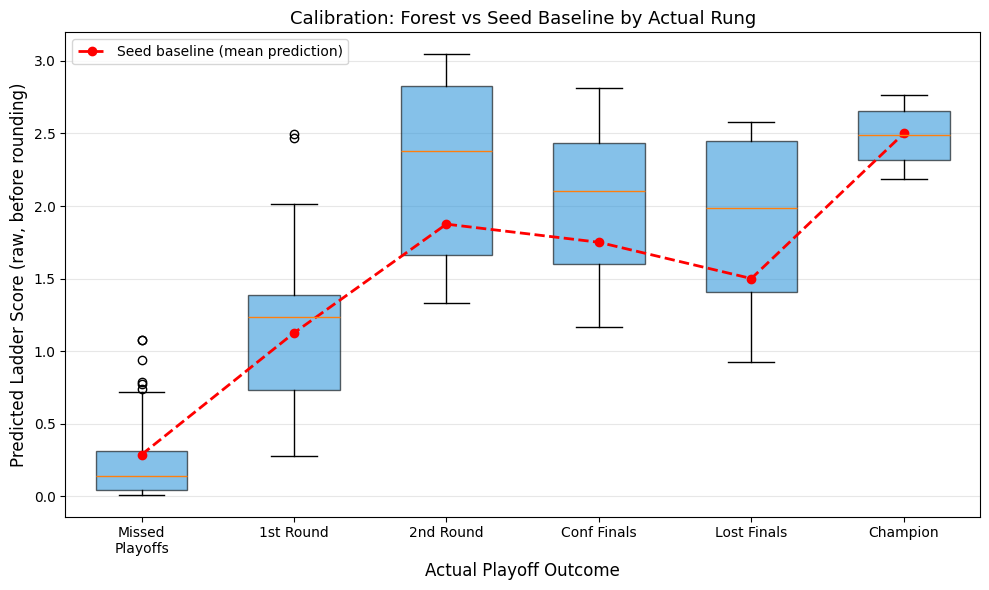

Mean prediction by actual ladder score (test set):
        model_mean  baseline_mean   n
actual                               
0            0.246          0.286  56
1            1.206          1.125  32
2            2.269          1.875  16
3            2.024          1.750   8
4            1.870          1.500   4
5            2.482          2.500   4


In [21]:
# CALIBRATION — model raw predictions vs the "just pick higher seed" baseline
ladder_labels = {0: 'Missed\nPlayoffs', 1: '1st Round', 2: '2nd Round',
                 3: 'Conf Finals', 4: 'Lost Finals', 5: 'Champion'}

calib = pd.DataFrame({
    'actual':   y_test.values,
    'pred_raw': y_pred_best_raw,
    'baseline': test['baseline_pred'].values,
})
order  = sorted(calib['actual'].unique())
data   = [calib.loc[calib['actual'] == s, 'pred_raw'].values for s in order]
labels = [ladder_labels[s] for s in order]
baseline_means = [calib.loc[calib['actual'] == s, 'baseline'].mean() for s in order]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(data, labels=labels, widths=0.6, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.6)

# Red reference line: just-pick-higher-seed baseline (mean prediction per actual rung)
ax.plot(range(1, len(order) + 1), baseline_means, 'r--o', linewidth=2,
        label='Seed baseline (mean prediction)')

ax.set_xlabel('Actual Playoff Outcome', fontsize=12)
ax.set_ylabel('Predicted Ladder Score (raw, before rounding)', fontsize=12)
ax.set_title(f'Calibration: {best_name} vs Seed Baseline by Actual Rung', fontsize=13)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean prediction by actual ladder score (test set):")
summary = calib.groupby('actual').agg(
    model_mean=('pred_raw', 'mean'),
    baseline_mean=('baseline', 'mean'),
    n=('actual', 'count'),
).round(3)
print(summary)

## Conclusions

**Top-line finding:**
> The model is a **tier-ranking tool**, not a perfect playoff-round predictor. It cleanly separates non-playoff teams from playoff teams and ranks contenders within the playoff field, but it cannot pick *the* champion from regular-season stats alone. The Random Forest beats the seed-only baseline on the held-out window (MAE 0.458 vs 0.500, accuracy 64.2% vs 63.3%).

**What we built:** Four regression approaches (all from the rubric's allowed model list) predicting NBA playoff success (`ladder_score` 0–5) from regular-season statistics, evaluated on a held-out test set (2019–2022, 120 teams).

### Models compared

| Model | MAE | Accuracy |
|---|---|---|
| Ridge / Linear Regression | 0.533 | 55.8% |
| Decision Tree (depth 5, CV-tuned) | 0.467 | 64.2% |
| **Random Forest (300 trees)** | **0.458** | **64.2%** |
| k-Nearest Neighbors (k=7, CV-tuned) | 0.525 | 58.3% |
| Seed baseline | 0.500 | 63.3% |

### Where the model is strong vs weak

**Strong:**
- Distinguishing playoff teams from non-playoff teams — the lower half of the ladder is the model's accurate range.
- Tier-ranking — predicted-vs-actual is roughly monotonic across rungs.

**Weak:**
- The model **never predicts `ladder_score = 5`** for any team — champions are too rare for the rounded prediction to land there, so picking a champion needs post-processing (e.g. taking the highest raw score).
- The deepest tiers (Conf Finals, Finals, Champion) cannot be cleanly separated using regular-season stats alone.

### Limitations
- Test set is small (120 teams over 4 seasons) — the improvement over baseline is real but modest.
- No injury, rest, or playoff-matchup features.

## Team Contribution

| Role | Member | Contribution |
|------|--------|--------------|
| Data Engineer | William Haufrect | Sets up the environment (repo, data pipeline, requirements, codespace, clean and prep data). *e.g. season filter, unstacking games to team perspective.* |
| Researcher | William Haufrect | Background and question building. *e.g. framing the ladder-score target, motivating the seed-based baseline.* |
| Model Builder | Toby Draper | Builds initial models for testing. *e.g. CV-tuned Tree and kNN, Random Forest, walk-forward CV.* |
| "Red Team" | Toby Draper | Evaluates the model and reviews the code for quality or performance gaps. *e.g. bootstrap CIs, no-seed robustness check, caught the league-wide-vs-conference seeding bug.* |
| Final Reviewer | William Haufrect | One last run through all the content to ensure quality and clear message. *e.g. verifying prose numbers match live outputs, fresh-kernel re-run.* |